# EEG-Based Alzheimer Detection — Leakage-Safe Deep Learning Pipeline
## 4-Class Classification: **Healthy | Mild | Moderate | Severe**
### Models: Multi-Scale CNN · CNN+Attention · Stacked LSTM · CNN+LSTM · CNN+BiLSTM+Attention · EEG Transformer
### Evaluation: **subject-level hold-out test + 5-fold Stratified Group CV**

> **Important:** HMMS.csv does not contain an explicit subject-ID column. The dataset's row counts match the documented subject layout exactly (23 Healthy, 8 Mild, 12 Moderate, 10 Severe), so this notebook reconstructs subject groups from the ordered class blocks and verifies the expected counts before training.

### Leakage controls
- Subject-level train/test split — no subject appears in both sets.
- Subject-level grouped CV — no subject appears in both training and validation within a fold.
- Windows are created **inside each subject only**; no window crosses subjects.
- Non-overlapping 1-second windows (`stride = window`) to avoid near-duplicate samples.
- Class balancing uses **training-only class weights**; no validation/test samples are discarded.
- Per-segment normalization uses only the segment itself.
- The independent test set is used **once**, after model selection.
- Primary CV/test metrics are **subject-level macro F1/accuracy**, with segment-level metrics reported separately.


In [ ]:
# Download Dataset
!gdown --id 1GZyHxtjJbIVjT75yxcLiIgKeMd72KmcG -O HMMS.csv
!ls -lh HMMS.csv


/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1GZyHxtjJbIVjT75yxcLiIgKeMd72KmcG
From (redirected): https://drive.google.com/uc?id=1GZyHxtjJbIVjT75yxcLiIgKeMd72KmcG&confirm=t&uuid=94ad51f9-b755-4552-9e9e-5ca43f0b2675
To: /content/HMMS.csv
100% 295M/295M [00:06<00:00, 48.9MB/s]
-rw-r--r-- 1 root root 282M Feb 22  2026 HMMS.csv


In [ ]:
# Imports
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Load & Inspect Data
# HMMS.csv contains 19 EEG channels/features plus the class label.
data = pd.read_csv('HMMS.csv')

# The original notebook dropped the first column as an index. Keep that behaviour,
# but only when it is not one of the 19 EEG features or the label.
if 'label' not in data.columns:
    raise ValueError("HMMS.csv must contain a 'label' column.")

if data.columns[0] != 'label' and data.columns[0].lower() in {'unnamed: 0', 'index', 'id'}:
    data = data.iloc[:, 1:]

feature_cols = [c for c in data.columns if c != 'label']
if len(feature_cols) < 19:
    raise ValueError(f"Expected at least 19 EEG feature columns, found {len(feature_cols)}.")

X_raw = data[feature_cols[:19]].to_numpy(dtype=np.float32)
y_raw = data['label'].astype(str).to_numpy()

le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
CLASS_NAMES = list(le.classes_)
N_CLASSES = len(CLASS_NAMES)

print('Detected classes  :', CLASS_NAMES)
print('Number of classes :', N_CLASSES)
print('Raw EEG shape     :', X_raw.shape)
print('Label distribution:')
for i, name in enumerate(CLASS_NAMES):
    cnt = np.sum(y_encoded == i)
    print(f'  [{i}] {name:<10s} : {cnt:>7d}  ({100*cnt/len(y_encoded):.1f} %)')

if N_CLASSES != 4:
    raise ValueError('This notebook expects exactly 4 Alzheimer classes.')


Detected classes  : ['Healthy', 'Mild', 'Moderate', 'Sever']
Number of classes : 4
Raw EEG shape     : (473552, 19)
Label distribution:
  [0] Healthy    :   23552  (5.0 %)
  [1] Mild       :  120000  (25.3 %)
  [2] Moderate   :  180000  (38.0 %)
  [3] Sever      :  150000  (31.7 %)


In [ ]:
# Reconstruct subject groups from the ordered HMMS class blocks
#
# HMMS.csv has no subject-ID column. Its class totals match the documented
# subject layout exactly:
#   Healthy  = 23 subjects × 1,024 rows
#   Mild     =  8 subjects × 15,000 rows
#   Moderate = 12 subjects × 15,000 rows
#   Severe   = 10 subjects × 15,000 rows
#
# We verify these assumptions instead of silently guessing. If a different
# version of HMMS.csv is supplied, the notebook stops and asks for subject IDs.
EXPECTED_SUBJECTS_PER_CLASS = {
    'Healthy': 23,
    'Mild': 8,
    'Moderate': 12,
    'Severe': 10,
    'Sever': 10,  # spelling used by the supplied HMMS.csv
}

subject_id_raw = np.full(len(y_raw), -1, dtype=np.int32)
subject_label_raw = np.empty(len(y_raw), dtype=object)
subject_counter = 0
subject_summary = []

for class_name in CLASS_NAMES:
    idx = np.flatnonzero(y_raw == class_name)
    expected_n = EXPECTED_SUBJECTS_PER_CLASS.get(class_name)
    if expected_n is None:
        raise ValueError(
            f"No subject-count rule for class '{class_name}'. "
            "Provide an explicit subject_id column/metadata before training."
        )

    # A subject-aware reconstruction is only valid when each class is stored
    # as one ordered block in HMMS.csv.
    if len(idx) == 0 or not np.all(np.diff(idx) == 1):
        raise ValueError(
            f"Rows for class '{class_name}' are not one contiguous block. "
            "The CSV does not expose subject IDs, so a leakage-safe subject split "
            "cannot be reconstructed automatically."
        )

    if len(idx) % expected_n != 0:
        raise ValueError(
            f"Class '{class_name}' has {len(idx):,} rows, which is not divisible "
            f"by the expected {expected_n} subjects. Check HMMS.csv or supply metadata."
        )

    rows_per_subject = len(idx) // expected_n
    for local_sid in range(expected_n):
        a = local_sid * rows_per_subject
        b = (local_sid + 1) * rows_per_subject
        rows = idx[a:b]
        subject_id_raw[rows] = subject_counter
        subject_label_raw[rows] = class_name
        subject_summary.append({
            'subject_id': subject_counter,
            'class': class_name,
            'rows': len(rows)
        })
        subject_counter += 1

if np.any(subject_id_raw < 0):
    raise RuntimeError('Some raw rows were not assigned to a subject.')

subject_df = pd.DataFrame(subject_summary)
print(f'\nReconstructed subjects: {len(subject_df)}')
print(subject_df.groupby('class').size().to_string())
print('\nRows per subject by class:')
print(subject_df.groupby('class')['rows'].agg(['count','min','max']).to_string())



Reconstructed subjects: 53
class
Healthy     23
Mild         8
Moderate    12
Sever       10

Rows per subject by class:
          count    min    max
class                        
Healthy      23   1024   1024
Mild          8  15000  15000
Moderate     12  15000  15000
Sever        10  15000  15000


In [ ]:
# Subject-level hold-out split BEFORE segmentation
# 20% of subjects are held out permanently as the independent test set.
subject_labels = subject_df['class'].to_numpy()
subject_ids = subject_df['subject_id'].to_numpy()

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
dev_pos, test_pos = next(sss.split(subject_ids, subject_labels))

dev_subjects = subject_ids[dev_pos]
test_subjects = subject_ids[test_pos]

dev_subject_set = set(dev_subjects.tolist())
test_subject_set = set(test_subjects.tolist())

print('Development subjects:', len(dev_subjects))
print('Test subjects       :', len(test_subjects))
print('\nDevelopment class counts:')
print(subject_df[subject_df.subject_id.isin(dev_subjects)].groupby('class').size().to_string())
print('\nTest class counts:')
print(subject_df[subject_df.subject_id.isin(test_subjects)].groupby('class').size().to_string())

assert dev_subject_set.isdisjoint(test_subject_set)


Development subjects: 42
Test subjects       : 11

Development class counts:
class
Healthy     18
Mild         6
Moderate    10
Sever        8

Test class counts:
class
Healthy     5
Mild        2
Moderate    2
Sever       2


In [ ]:
# Segment each subject independently — NON-OVERLAPPING 1-second windows
fs = 250
window = fs
stride = window

segments = []
segment_labels = []
segment_subjects = []

for sid in subject_ids:
    rows = np.flatnonzero(subject_id_raw == sid)
    # rows are contiguous by construction; use them only within this subject.
    X_sub = X_raw[rows]
    y_sub = y_encoded[rows]
    class_id = int(y_sub[0])

    if not np.all(y_sub == class_id):
        raise RuntimeError(f'Subject {sid} contains multiple labels.')

    for start in range(0, len(X_sub) - window + 1, stride):
        seg = X_sub[start:start + window]
        segments.append(seg)
        segment_labels.append(class_id)
        segment_subjects.append(sid)

X = np.asarray(segments, dtype=np.float32)
y = np.asarray(segment_labels, dtype=np.int32)
groups = np.asarray(segment_subjects, dtype=np.int32)

# Per-segment z-score: uses only the current segment, so no train/test statistics leak.
seg_mean = X.mean(axis=1, keepdims=True)
seg_std = X.std(axis=1, keepdims=True) + 1e-8
X = (X - seg_mean) / seg_std

print('Segmented X shape:', X.shape)
print('Segments per subject:')
print(pd.Series(groups).value_counts().describe().to_string())

# Hard safety checks: every segment belongs to exactly one subject and one class.
assert len(X) == len(y) == len(groups)
assert np.all([len(np.unique(y[groups == sid])) == 1 for sid in np.unique(groups)])

print('\nSegment distribution:')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:<10s}: {np.sum(y == i):>6d}')


Segmented X shape: (1892, 250, 19)
Segments per subject:
count    53.000000
mean     35.698113
std      28.020312
min       4.000000
25%       4.000000
50%      60.000000
75%      60.000000
max      60.000000

Segment distribution:
  Healthy   :     92
  Mild      :    480
  Moderate  :    720
  Sever     :    600


In [ ]:
# Shared Attention Blocks

#  Channel Attention — SE Block
def channel_attention(x, ratio=8):
    """
    Squeeze-and-Excitation style channel attention.
    Input : (B, T, C)  →  Output: (B, T, C)
    Learns which of the 19 EEG channels are diagnostically relevant.
    """
    c   = x.shape[-1]
    gap = layers.GlobalAveragePooling1D()(x)                  # (B, C)
    se  = layers.Dense(max(c // ratio, 1), activation='relu')(gap)
    se  = layers.Dense(c, activation='sigmoid')(se)           # (B, C)
    se  = layers.Reshape((1, c))(se)                          # (B, 1, C)
    return layers.Multiply()([x, se])


# Temporal Attention
def temporal_attention(x):
    """
    Soft temporal attention over time-steps.
    Input : (B, T, C)  →  Output: (B, T, C)
    Learns which time steps carry the most class-discriminative signal.
    """
    score = layers.Dense(1, activation='tanh')(x)    # (B, T, 1)
    score = layers.Softmax(axis=1)(score)            # (B, T, 1)
    return layers.Multiply()([x, score])             # (B, T, C)


# Sinusoidal Positional Encoding
class PositionalEncoding(layers.Layer):
    def __init__(self, max_len=250, d_model=64, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len
        self.d_model = d_model

    def build(self, input_shape):
        pos    = np.arange(self.max_len)[:, np.newaxis]
        dims   = np.arange(self.d_model)[np.newaxis, :]
        angles = pos / np.power(10000, (2 * (dims // 2)) / self.d_model)
        angles[:, 0::2] = np.sin(angles[:, 0::2])
        angles[:, 1::2] = np.cos(angles[:, 1::2])
        self.pe = tf.cast(angles[np.newaxis, :, :], tf.float32)  # (1, T, D)
        super().build(input_shape)

    def call(self, x):
        return x + self.pe[:, :tf.shape(x)[1], :]

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'max_len': self.max_len, 'd_model': self.d_model})
        return cfg


print('Shared attention blocks defined.')

Shared attention blocks defined.


In [ ]:
#  Model 1 — Multi-Scale 1D CNN
"""
5 parallel CNN branches with different temporal receptive fields.
The kernel sizes are NOT fixed EEG frequency bands; they simply let the
network learn patterns at different temporal scales.
Output: 4-class softmax.
"""

def build_multiscale_cnn(input_shape=(250, 19), n_classes=N_CLASSES):
    inp = Input(shape=input_shape, name='eeg_input')

    branches = []
    for k in [3, 7, 15, 31, 63]:
        b = layers.Conv1D(32, k, padding='same', use_bias=False)(inp)
        b = layers.BatchNormalization()(b)
        b = layers.Activation('relu')(b)
        b = layers.Conv1D(64, k, padding='same', use_bias=False)(b)
        b = layers.BatchNormalization()(b)
        b = layers.Activation('relu')(b)
        b = layers.MaxPooling1D(4)(b)
        b = layers.Dropout(0.3)(b)
        branches.append(b)

    x = layers.Concatenate()(branches)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    # 4-class softmax output
    out = layers.Dense(n_classes, activation='softmax', name='output')(x)

    return Model(inp, out, name='MultiScale_CNN')


build_multiscale_cnn().summary()

Model: "MultiScale_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eeg_input           │ (None, 250, 19)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 250, 32)   │      1,824 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 250, 32)   │      4,256 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 250, 32)   │      9,120 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 250, 32)   │     18,848 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 250, 32)   │     38,304 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 250, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 32)   │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 32)   │        128 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 32)   │        128 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 32)   │        128 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 250, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 250, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 250, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 250, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 250, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 250, 64)   │      6,144 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 250, 64)   │     14,336 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 250, 64)   │     30,720 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 475,556 (1.81 MB)

 Trainable params: 474,340 (1.81 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [ ]:
# Model 2 — CNN + Channel & Temporal Attention

def build_cnn_attention(input_shape=(250, 19), n_classes=N_CLASSES):
    inp = Input(shape=input_shape, name='eeg_input')

    branches = []
    for k in [3, 7, 15, 31]:
        b = layers.Conv1D(64, k, padding='same', use_bias=False)(inp)
        b = layers.BatchNormalization()(b)
        b = layers.Activation('relu')(b)
        branches.append(b)
    x = layers.Concatenate()(branches)

    x = layers.Conv1D(128, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = channel_attention(x, ratio=8)        # learn channel importance

    x = layers.Conv1D(128, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(4)(x)

    x = temporal_attention(x)               # learn timestep importance

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(n_classes, activation='softmax', name='output')(x)

    return Model(inp, out, name='CNN_Attention')


build_cnn_attention().summary()

Model: "CNN_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eeg_input           │ (None, 250, 19)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 250, 64)   │      3,648 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 250, 64)   │      8,512 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 250, 64)   │     18,240 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 250, 64)   │     37,696 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 64)   │        256 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 64)   │        256 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 64)   │        256 │ conv1d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 64)   │        256 │ conv1d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 250, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 250, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 250, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 250, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 250, 256)  │          0 │ activation_10[0]… │
│ (Concatenate)       │                   │            │ activation_11[0]… │
│                     │                   │            │ activation_12[0]… │
│                     │                   │            │ activation_13[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 250, 128)  │     98,304 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 128)  │        512 │ conv1d_15[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 250, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ activation_14[0]

 Total params: 256,021 (1000.08 KB)

 Trainable params: 254,997 (996.08 KB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:
# Model 3 — Stacked LSTM  (CuDNN-compatible, fast on GPU)
# FIX 1: recurrent_dropout removed  → enables CuDNN kernel (10–20× faster)
# FIX 2: Conv1D downsamples 250→62 timesteps before LSTM (saves ~4× memory)
# FIX 3: standard dropout kept on dense layers for regularisation

def build_stacked_lstm(input_shape=(250, 19), n_classes=N_CLASSES):
    inp = Input(shape=input_shape, name='eeg_input')

    # Temporal downsampling via strided Conv1D
    # Reduces 250 timesteps → 62 while learning local EEG patterns
    x = layers.Conv1D(64, kernel_size=7, strides=2,
                       padding='same', use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv1D(64, kernel_size=5, strides=2,
                       padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)   # (B, 63, 64)
    x = layers.Dropout(0.2)(x)

    # Stacked LSTM — NO recurrent_dropout (preserves CuDNN path)
    x = layers.LSTM(128, return_sequences=True,
                     dropout=0.3)(x)           # ✓ CuDNN-safe
    x = layers.LSTM(128, return_sequences=True,
                     dropout=0.3)(x)           # ✓ CuDNN-safe
    x = layers.LSTM(64,  return_sequences=False,
                     dropout=0.3)(x)           # ✓ CuDNN-safe

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(n_classes, activation='softmax', name='output')(x)

    return Model(inp, out, name='Stacked_LSTM')


build_stacked_lstm().summary()

Model: "Stacked_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)          │ (None, 250, 19)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 125, 64)        │         8,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 125, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 125, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 63, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 63, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 63, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 63, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 318,148 (1.21 MB)

 Trainable params: 317,892 (1.21 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
# Model 4 — CNN + LSTM Hybrid

def build_cnn_lstm(input_shape=(250, 19), n_classes=N_CLASSES):
    inp = Input(shape=input_shape, name='eeg_input')

    # Spatial feature extraction via CNN
    x = layers.Conv1D(64, 7, padding='same', use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv1D(128, 5, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)           # (B, 125, 128)
    x = layers.Dropout(0.3)(x)

    x = channel_attention(x, ratio=8)      # channel gating before LSTM

    # Temporal modelling via LSTM
    x = layers.LSTM(128, return_sequences=True,  dropout=0.3)(x)
    x = layers.LSTM(64,  return_sequences=False, dropout=0.3)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(n_classes, activation='softmax', name='output')(x)

    return Model(inp, out, name='CNN_LSTM')


build_cnn_lstm().summary()

Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eeg_input           │ (None, 250, 19)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 250, 64)   │      8,512 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 64)   │        256 │ conv1d_19[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 250, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 250, 128)  │     40,960 │ activation_18[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 128)  │        512 │ conv1d_20[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 250, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 125, 128)  │          0 │ activation_19[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 125, 128)  │          0 │ max_pooling1d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ dropout_9[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │      2,064 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │      2,176 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 128)    │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 125, 128)  │          0 │ dropout_9[0][0],  │
│ (Multiply)          │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 125, 128)  │    131,584 │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 64)        │     49,408 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │      8,320 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128)       │          0 │ dense_8[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 4)         │        516 │ dropout_10[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 244,308 (954.33 KB)

 Trainable params: 243,924 (952.83 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# Model 5 — CNN + BiLSTM + Attention

def build_cnn_bilstm_attention(input_shape=(250, 19), n_classes=N_CLASSES):
    inp = Input(shape=input_shape, name='eeg_input')

    # Multi-scale CNN backbone
    branches = []
    for k in [3, 7, 15, 31]:
        b = layers.Conv1D(64, k, padding='same', use_bias=False)(inp)
        b = layers.BatchNormalization()(b)
        b = layers.Activation('relu')(b)
        branches.append(b)
    x = layers.Concatenate()(branches)

    x = layers.Conv1D(128, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = channel_attention(x, ratio=8)
    x = layers.MaxPooling1D(2)(x)           # (B, 125, 128)
    x = layers.Dropout(0.3)(x)

    # Bidirectional LSTM — forward + backward temporal context
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.3))(x)
    x = layers.Bidirectional(
        layers.LSTM(64,  return_sequences=True, dropout=0.3))(x)

    x = temporal_attention(x)              # attention over BiLSTM outputs

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(n_classes, activation='softmax', name='output')(x)

    return Model(inp, out, name='CNN_BiLSTM_Attention')


build_cnn_bilstm_attention().summary()

Model: "CNN_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eeg_input           │ (None, 250, 19)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 250, 64)   │      3,648 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 250, 64)   │      8,512 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 250, 64)   │     18,240 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 250, 64)   │     37,696 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 64)   │        256 │ conv1d_21[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 64)   │        256 │ conv1d_22[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 64)   │        256 │ conv1d_23[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 64)   │        256 │ conv1d_24[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 250, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 250, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 250, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (None, 250, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 250, 256)  │          0 │ activation_20[0]… │
│ (Concatenate)       │                   │            │ activation_21[0]… │
│                     │                   │            │ activation_22[0]… │
│                     │                   │            │ activation_23[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 250, 128)  │     98,304 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 128)  │        512 │ conv1d_25[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_24       │ (None, 250, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ activation_24[0]

 Total params: 633,877 (2.42 MB)

 Trainable params: 633,109 (2.42 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
# Model 6 — EEG Transformer

"""
Transformer encoder for EEG sequence classification.

The input is first projected/downsampled to a 64-dimensional token sequence.
Sinusoidal positional encoding preserves temporal order, and two Transformer
encoder blocks model long-range dependencies across the 1-second EEG segment.
This is a genuine Transformer model and is evaluated through the same
subject-level, leakage-safe CV pipeline as the other models.
"""

def transformer_encoder(x, d_model=64, num_heads=4, ff_dim=128, dropout=0.2):
    # Pre-norm Transformer encoder block
    residual = x
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout
    )(x, x)
    x = layers.Dropout(dropout)(x)
    x = layers.Add()([residual, x])

    residual = x
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dense(ff_dim, activation=tf.nn.gelu)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(d_model)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Add()([residual, x])
    return x


def build_eeg_transformer(input_shape=(250, 19), n_classes=N_CLASSES):
    inp = Input(shape=input_shape, name='eeg_input')

    # Learn a compact temporal token representation.
    x = layers.Conv1D(64, kernel_size=7, strides=2, padding='same',
                      use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.1)(x)

    # Add temporal position information before self-attention.
    x = PositionalEncoding(max_len=input_shape[0], d_model=64)(x)

    # Two Transformer encoder blocks.
    x = transformer_encoder(x, d_model=64, num_heads=4, ff_dim=128, dropout=0.2)
    x = transformer_encoder(x, d_model=64, num_heads=4, ff_dim=128, dropout=0.2)

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(n_classes, activation='softmax', name='output')(x)

    return Model(inp, out, name='EEG_Transformer')


build_eeg_transformer().summary()


Model: "EEG_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eeg_input           │ (None, 250, 19)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 125, 64)   │      8,512 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 64)   │        256 │ conv1d_26[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_25       │ (None, 125, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 125, 64)   │          0 │ activation_25[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 125, 64)   │          0 │ dropout_13[0][0]  │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 125, 64)   │        128 │ positional_encod… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 125, 64)   │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 125, 64)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 125, 64)   │          0 │ positional_encod… │
│                     │                   │            │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 125, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 125, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 125, 128)  │          0 │ dense_13[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 125, 64)   │      8,256 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 125, 64)   │          0 │ dense_14[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 125, 64)   │          0 │ add[0][0],        │
│                     │                   │            │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 125, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 125, 64)   │     16,640 │ layer_normalizat

 Total params: 84,676 (330.77 KB)

 Trainable params: 84,548 (330.27 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
# Training configuration — leakage-safe group CV
from tensorflow.keras.metrics import Metric, SparseCategoricalAccuracy

class SparseMacroMetric(Metric):
    def __init__(self, num_classes, name, **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.tp = self.add_weight(shape=(num_classes,), initializer='zeros', name='tp')
        self.fp = self.add_weight(shape=(num_classes,), initializer='zeros', name='fp')
        self.fn = self.add_weight(shape=(num_classes,), initializer='zeros', name='fn')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        y_true_oh = tf.one_hot(y_true, self.num_classes)
        y_pred_oh = tf.one_hot(y_pred, self.num_classes)
        self.tp.assign_add(tf.reduce_sum(y_true_oh * y_pred_oh, axis=0))
        self.fp.assign_add(tf.reduce_sum((1 - y_true_oh) * y_pred_oh, axis=0))
        self.fn.assign_add(tf.reduce_sum(y_true_oh * (1 - y_pred_oh), axis=0))

    def reset_state(self):
        for v in self.variables:
            v.assign(tf.zeros_like(v))

class MacroPrecision(SparseMacroMetric):
    def __init__(self, num_classes, name='macro_precision', **kwargs):
        super().__init__(num_classes, name=name, **kwargs)
    def result(self):
        return tf.reduce_mean(self.tp / (self.tp + self.fp + 1e-7))

class MacroRecall(SparseMacroMetric):
    def __init__(self, num_classes, name='macro_recall', **kwargs):
        super().__init__(num_classes, name=name, **kwargs)
    def result(self):
        return tf.reduce_mean(self.tp / (self.tp + self.fn + 1e-7))

class MacroF1(SparseMacroMetric):
    def __init__(self, num_classes, name='macro_f1', **kwargs):
        super().__init__(num_classes, name=name, **kwargs)
    def result(self):
        p = self.tp / (self.tp + self.fp + 1e-7)
        r = self.tp / (self.tp + self.fn + 1e-7)
        return tf.reduce_mean(2 * p * r / (p + r + 1e-7))

EPOCHS = 60
BATCH = 32
N_FOLDS = 5
LR = 1e-3

MODEL_BUILDERS = {
    'MultiScale_CNN': build_multiscale_cnn,
    'CNN_Attention': build_cnn_attention,
    'Stacked_LSTM': build_stacked_lstm,
    'CNN_LSTM': build_cnn_lstm,
    'CNN_BiLSTM_Attention': build_cnn_bilstm_attention,
    'EEG_Transformer': build_eeg_transformer,
}

def compile_model(model, lr=LR):
    model.compile(
        optimizer=Adam(lr),
        loss='sparse_categorical_crossentropy',
        metrics=[
            SparseCategoricalAccuracy(name='accuracy'),
            MacroPrecision(num_classes=N_CLASSES),
            MacroRecall(num_classes=N_CLASSES),
            MacroF1(num_classes=N_CLASSES),
        ],
    )
    return model

def make_callbacks(model_name, fold):
    return [
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=0),
        ModelCheckpoint(
            f'best_{model_name}_fold{fold}.keras',
            monitor='val_loss', save_best_only=True, verbose=0
        ),
    ]

def training_class_weights(y_train):
    classes = np.arange(N_CLASSES)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    return {int(c): float(w) for c, w in zip(classes, weights)}

def subject_level_predictions(y_true, y_prob, subject_ids_for_segments):
    unique_subjects = np.unique(subject_ids_for_segments)
    subj_true, subj_pred, subj_prob = [], [], []
    for sid in unique_subjects:
        mask = subject_ids_for_segments == sid
        # All segments from a subject have the same ground-truth class.
        subj_true.append(int(y_true[mask][0]))
        mean_prob = np.mean(y_prob[mask], axis=0)
        subj_prob.append(mean_prob)
        subj_pred.append(int(np.argmax(mean_prob)))
    return (np.asarray(subj_true), np.asarray(subj_pred),
            np.asarray(subj_prob), unique_subjects)

print(f'Leakage-safe evaluation: {N_FOLDS}-fold StratifiedGroupKFold + independent subject test set')
print(f'Epochs={EPOCHS}, batch={BATCH}, learning_rate={LR}')


Leakage-safe evaluation: 5-fold StratifiedGroupKFold + independent subject test set
Epochs=60, batch=32, learning_rate=0.001


In [ ]:
# Subject-grouped cross-validation on DEVELOPMENT subjects only
# Validation folds contain completely unseen subjects. Test subjects are never used here.

dev_mask = np.isin(groups, dev_subjects)
test_mask = np.isin(groups, test_subjects)

X_dev, y_dev, g_dev = X[dev_mask], y[dev_mask], groups[dev_mask]
X_test, y_test, g_test = X[test_mask], y[test_mask], groups[test_mask]

assert set(g_dev).isdisjoint(set(g_test))

gkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

results = {}
histories = {}
cm_data = {}
per_class_rpt = {}
fold_predictions = {}

for model_name, builder in MODEL_BUILDERS.items():
    print('\n' + '=' * 72)
    print(f'  Model: {model_name}')
    print('=' * 72)

    fold_metrics = []
    fold_histories = []
    all_subject_true, all_subject_pred = [], []
    all_segment_true, all_segment_pred = [], []
    all_segment_prob = []
    all_segment_groups = []

    split_iter = gkf.split(X_dev, y_dev, groups=g_dev)

    for fold, (train_idx, val_idx) in enumerate(split_iter, 1):
        # Safety check: no subject can occur in both partitions.
        train_groups = set(g_dev[train_idx].tolist())
        val_groups = set(g_dev[val_idx].tolist())
        assert train_groups.isdisjoint(val_groups), 'GROUP LEAKAGE DETECTED'

        X_train, X_val = X_dev[train_idx], X_dev[val_idx]
        y_train, y_val = y_dev[train_idx], y_dev[val_idx]
        g_val = g_dev[val_idx]

        model = builder(input_shape=(window, 19), n_classes=N_CLASSES)
        model = compile_model(model)
        cw = training_class_weights(y_train)

        hist = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH,
            class_weight=cw,
            callbacks=make_callbacks(model_name, fold),
            verbose=0
        )
        fold_histories.append(hist.history)

        y_prob = model.predict(X_val, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)

        # Primary metric: subject-level performance.
        s_true, s_pred, s_prob, s_ids = subject_level_predictions(y_val, y_prob, g_val)
        acc = accuracy_score(s_true, s_pred)
        prec = precision_score(s_true, s_pred, average='macro', zero_division=0)
        rec = recall_score(s_true, s_pred, average='macro', zero_division=0)
        f1 = f1_score(s_true, s_pred, average='macro', zero_division=0)

        # Secondary metric: segment-level performance, retained for transparency.
        seg_acc = accuracy_score(y_val, y_pred)
        seg_f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)

        fold_metrics.append({
            'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1,
            'seg_acc': seg_acc, 'seg_f1': seg_f1,
            'best_epoch': int(np.argmin(hist.history['val_loss']) + 1),
            'n_val_subjects': len(s_ids),
        })

        all_subject_true.extend(s_true)
        all_subject_pred.extend(s_pred)
        all_segment_true.extend(y_val)
        all_segment_pred.extend(y_pred)
        all_segment_prob.append(y_prob)
        all_segment_groups.extend(g_val)

        print(
            f'  Fold {fold}/{N_FOLDS} | subjects={len(s_ids):2d} | '
            f'Subj Acc={acc:.4f} F1={f1:.4f} | '
            f'Seg Acc={seg_acc:.4f} F1={seg_f1:.4f}'
        )

        keras.backend.clear_session()

    subject_true = np.asarray(all_subject_true)
    subject_pred = np.asarray(all_subject_pred)
    cm = confusion_matrix(subject_true, subject_pred, labels=np.arange(N_CLASSES))
    report = classification_report(
        subject_true, subject_pred, target_names=CLASS_NAMES,
        labels=np.arange(N_CLASSES), zero_division=0, output_dict=True
    )

    mean_acc = np.mean([m['acc'] for m in fold_metrics])
    std_acc = np.std([m['acc'] for m in fold_metrics])
    mean_prec = np.mean([m['prec'] for m in fold_metrics])
    mean_rec = np.mean([m['rec'] for m in fold_metrics])
    mean_f1 = np.mean([m['f1'] for m in fold_metrics])
    std_f1 = np.std([m['f1'] for m in fold_metrics])

    results[model_name] = {
        'acc': (mean_acc, std_acc),
        'prec': mean_prec,
        'rec': mean_rec,
        'f1': (mean_f1, std_f1),
        'seg_acc': np.mean([m['seg_acc'] for m in fold_metrics]),
        'seg_f1': np.mean([m['seg_f1'] for m in fold_metrics]),
        'best_epoch': int(np.median([m['best_epoch'] for m in fold_metrics])),
    }
    histories[model_name] = fold_histories
    cm_data[model_name] = cm
    per_class_rpt[model_name] = report
    fold_predictions[model_name] = {
        'subject_true': subject_true,
        'subject_pred': subject_pred,
    }

    print(f'\n  {model_name} — subject-level CV')
    print(f'  Accuracy : {mean_acc:.4f} ± {std_acc:.4f}')
    print(f'  Macro-F1 : {mean_f1:.4f} ± {std_f1:.4f}')
    print(f'  Median best epoch: {results[model_name]["best_epoch"]}')



  Model: MultiScale_CNN
  Fold 1/5 | subjects= 9 | Subj Acc=0.6667 F1=0.5417 | Seg Acc=0.4968 F1=0.6056
  Fold 2/5 | subjects= 9 | Subj Acc=0.8889 F1=0.8667 | Seg Acc=0.7025 F1=0.7607
  Fold 3/5 | subjects= 8 | Subj Acc=1.0000 F1=1.0000 | Seg Acc=0.8672 F1=0.6753
  Fold 4/5 | subjects= 8 | Subj Acc=1.0000 F1=1.0000 | Seg Acc=0.9185 F1=0.9222
  Fold 5/5 | subjects= 8 | Subj Acc=0.2500 F1=0.3125 | Seg Acc=0.4023 F1=0.4476

  MultiScale_CNN — subject-level CV
  Accuracy : 0.7611 ± 0.2831
  Macro-F1 : 0.7442 ± 0.2732
  Median best epoch: 2

  Model: CNN_Attention
  Fold 1/5 | subjects= 9 | Subj Acc=0.6667 F1=0.5417 | Seg Acc=0.4494 F1=0.5610
  Fold 2/5 | subjects= 9 | Subj Acc=0.7778 F1=0.7976 | Seg Acc=0.7911 F1=0.8233
  Fold 3/5 | subjects= 8 | Subj Acc=0.8750 F1=0.8222 | Seg Acc=0.7852 F1=0.8343
  Fold 4/5 | subjects= 8 | Subj Acc=0.7500 F1=0.7417 | Seg Acc=0.6957 F1=0.6413
  Fold 5/5 | subjects= 8 | Subj Acc=0.7500 F1=0.6250 | Seg Acc=0.5273 F1=0.6593

  CNN_Attention — subject-level 

In [ ]:
# Model comparison — PRIMARY results are SUBJECT-LEVEL CV metrics
rows = []
for model_name, metrics in results.items():
    row = {
        'Model': model_name,
        'Accuracy': metrics['acc'][0],
        'Acc_Std': metrics['acc'][1],
        'Macro_Precision': metrics['prec'],
        'Macro_Recall': metrics['rec'],
        'Macro_F1': metrics['f1'][0],
        'F1_Std': metrics['f1'][1],
        'Segment_Accuracy': metrics['seg_acc'],
        'Segment_Macro_F1': metrics['seg_f1'],
        'Median_Best_Epoch': metrics['best_epoch'],
    }
    for cls in CLASS_NAMES:
        row[f'F1_{cls}'] = per_class_rpt[model_name][cls]['f1-score']
    rows.append(row)

results_df = pd.DataFrame(rows).sort_values('Macro_F1', ascending=False).reset_index(drop=True)

disp = results_df.copy()
for col in ['Accuracy','Acc_Std','Macro_Precision','Macro_Recall','Macro_F1','F1_Std',
            'Segment_Accuracy','Segment_Macro_F1'] + [f'F1_{c}' for c in CLASS_NAMES]:
    disp[col] = (disp[col] * 100).round(2)

print('\n' + '=' * 120)
print('SUBJECT-LEVEL 4-CLASS EEG ALZHEIMER CLASSIFICATION — LEAKAGE-SAFE CV')
print('=' * 120)
print(disp.to_string(index=False))
print('=' * 120)

best_model_name = results_df.iloc[0]['Model']
print(f'\nBest model selected using DEVELOPMENT-SET subject-level CV: {best_model_name}')
print('The independent test set has not been used for model selection.')



SUBJECT-LEVEL 4-CLASS EEG ALZHEIMER CLASSIFICATION — LEAKAGE-SAFE CV
               Model  Accuracy  Acc_Std  Macro_Precision  Macro_Recall  Macro_F1  F1_Std  Segment_Accuracy  Segment_Macro_F1  Median_Best_Epoch  F1_Healthy  F1_Mild  F1_Moderate  F1_Sever
            CNN_LSTM     86.11    13.38            86.25         86.25     82.79   16.40             71.30             73.94                  3       97.14    90.91        76.92     66.67
      MultiScale_CNN     76.11    28.31            76.55         77.50     74.42   27.32             67.75             68.23                  2       87.50    90.91        64.29     61.54
        Stacked_LSTM     75.83    21.11            78.10         77.50     72.89   21.38             73.85             69.31                  2       83.87    80.00        81.82     57.14
       CNN_Attention     76.39     6.69            75.83         72.36     70.56   10.65             64.97             70.38                  3       97.14    80.00        57.14 

In [ ]:
# Final independent test evaluation — BEST MODEL ONLY
#
# The architecture was selected from development-set subject-level CV.
# Training duration is fixed to the median best epoch observed during CV.
# The independent test subjects are evaluated exactly once here.

best_model_name = results_df.iloc[0]['Model']
best_builder = MODEL_BUILDERS[best_model_name]
final_epochs = int(results[best_model_name]['best_epoch'])

final_model = best_builder(input_shape=(window, 19), n_classes=N_CLASSES)
final_model = compile_model(final_model)
final_class_weights = training_class_weights(y_dev)

print(f'Training final {best_model_name} on all development subjects...')
print(f'Fixed epochs from CV: {final_epochs}')

final_model.fit(
    X_dev, y_dev,
    epochs=final_epochs,
    batch_size=BATCH,
    class_weight=final_class_weights,
    verbose=1
)

# Segment-level predictions (secondary)
test_prob = final_model.predict(X_test, verbose=0)
test_seg_pred = np.argmax(test_prob, axis=1)

# Subject-level predictions (PRIMARY)
test_true, test_pred, test_subj_prob, test_subj_ids = subject_level_predictions(
    y_test, test_prob, g_test
)

test_acc = accuracy_score(test_true, test_pred)
test_prec = precision_score(test_true, test_pred, average='macro', zero_division=0)
test_rec = recall_score(test_true, test_pred, average='macro', zero_division=0)
test_f1 = f1_score(test_true, test_pred, average='macro', zero_division=0)
test_cm = confusion_matrix(test_true, test_pred, labels=np.arange(N_CLASSES))

seg_test_acc = accuracy_score(y_test, test_seg_pred)
seg_test_f1 = f1_score(y_test, test_seg_pred, average='macro', zero_division=0)

print('\n' + '=' * 75)
print('INDEPENDENT SUBJECT-LEVEL TEST RESULTS')
print('=' * 75)
print(f'Test subjects       : {len(test_subj_ids)}')
print(f'Subject Accuracy    : {test_acc:.4f}')
print(f'Subject Macro-Prec. : {test_prec:.4f}')
print(f'Subject Macro-Recall: {test_rec:.4f}')
print(f'Subject Macro-F1    : {test_f1:.4f}')
print(f'Segment Accuracy    : {seg_test_acc:.4f}  (secondary)')
print(f'Segment Macro-F1    : {seg_test_f1:.4f}  (secondary)')
print('\nSubject-level confusion matrix:')
print(test_cm)
print('\nSubject-level classification report:')
print(classification_report(
    test_true, test_pred, target_names=CLASS_NAMES,
    labels=np.arange(N_CLASSES), zero_division=0, digits=4
))

test_report = classification_report(
    test_true, test_pred, target_names=CLASS_NAMES,
    labels=np.arange(N_CLASSES), zero_division=0, output_dict=True
)

final_model.save(f'FINAL_{best_model_name}_subject_safe.keras')
print(f'Saved: FINAL_{best_model_name}_subject_safe.keras')


Training final CNN_LSTM on all development subjects...
Fixed epochs from CV: 3
Epoch 1/3
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6157 - loss: 0.8958 - macro_f1: 0.5722 - macro_precision: 0.5612 - macro_recall: 0.6180
Epoch 2/3
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7493 - loss: 0.4939 - macro_f1: 0.7348 - macro_precision: 0.7137 - macro_recall: 0.7961
Epoch 3/3
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8122 - loss: 0.3137 - macro_f1: 0.8236 - macro_precision: 0.8015 - macro_recall: 0.8592

INDEPENDENT SUBJECT-LEVEL TEST RESULTS
Test subjects       : 11
Subject Accuracy    : 0.9091
Subject Macro-Prec. : 0.9167
Subject Macro-Recall: 0.8750
Subject Macro-F1    : 0.8667
Segment Accuracy    : 0.7553  (secondary)
Segment Macro-F1    : 0.7260  (secondary)

Subject-level confusion matrix:
[[5 0 0 0]
 [0 2 0 0]
 [0 0 2 0]
 [0 0 1 1]]

Subject-level classification report:
              precision    recall  f1-score   support

     Healthy     1.0000    1.

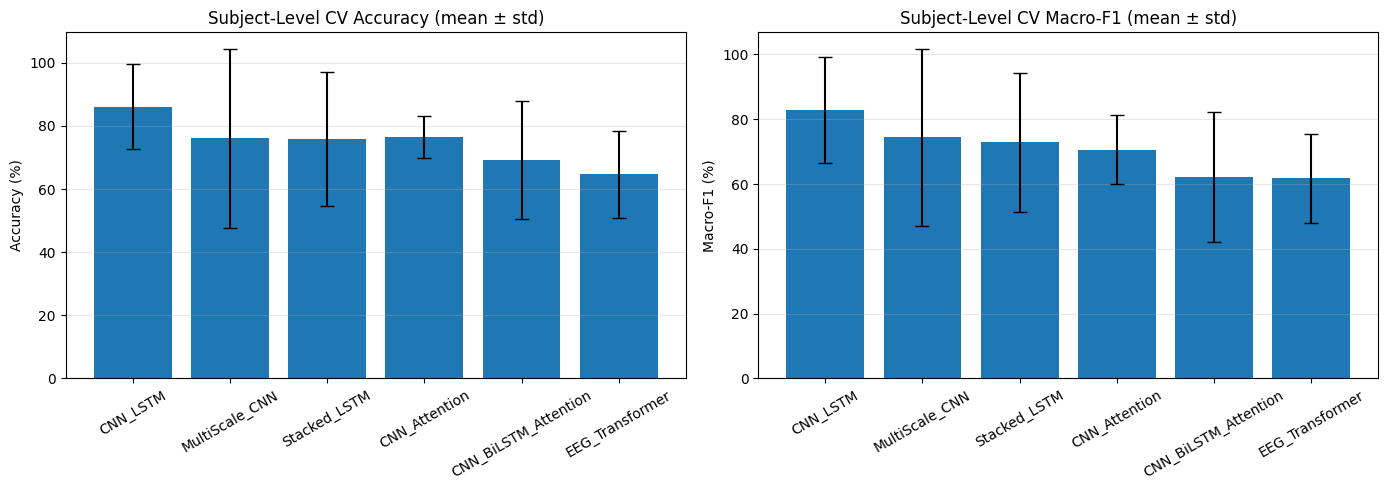

In [ ]:
# Diagnostic plot — subject-level CV accuracy and Macro-F1
plot_df = results_df.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(plot_df['Model'], plot_df['Accuracy'] * 100, yerr=plot_df['Acc_Std'] * 100, capsize=5)
axes[0].set_title('Subject-Level CV Accuracy (mean ± std)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(plot_df['Model'], plot_df['Macro_F1'] * 100, yerr=plot_df['F1_Std'] * 100, capsize=5)
axes[1].set_title('Subject-Level CV Macro-F1 (mean ± std)')
axes[1].set_ylabel('Macro-F1 (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('subject_level_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


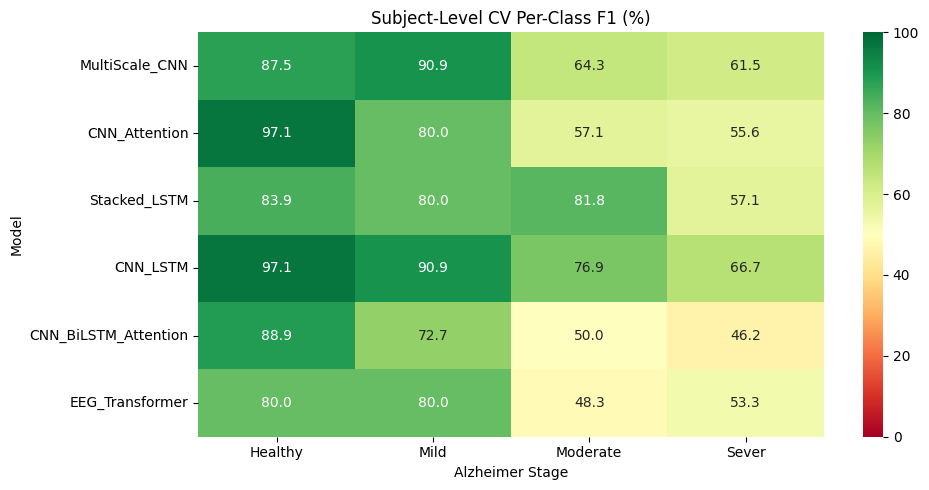

In [ ]:
# Subject-level CV per-class F1 heatmap
per_class_df = pd.DataFrame(
    {m: {cls: per_class_rpt[m][cls]['f1-score'] for cls in CLASS_NAMES}
     for m in MODEL_BUILDERS.keys()}
).T * 100

plt.figure(figsize=(10, 5))
sns.heatmap(per_class_df, annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=100)
plt.title('Subject-Level CV Per-Class F1 (%)')
plt.xlabel('Alzheimer Stage')
plt.ylabel('Model')
plt.tight_layout()
plt.savefig('subject_level_cv_per_class_f1.png', dpi=150)
plt.show()


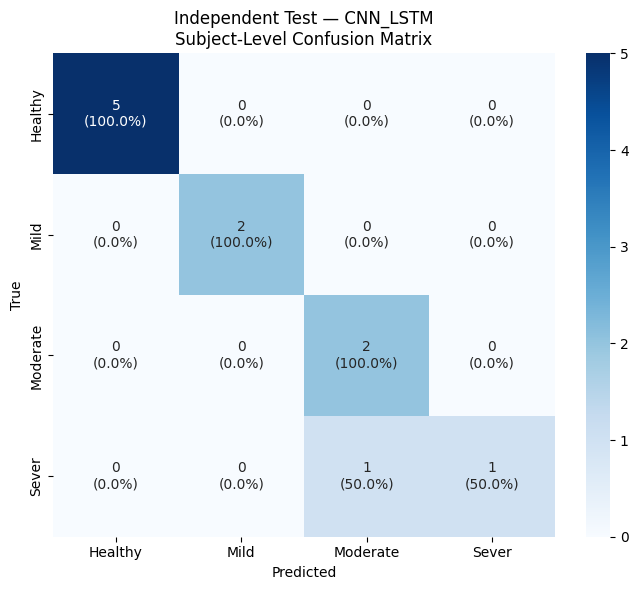

In [ ]:
# Independent test confusion matrix — PRIMARY result
plt.figure(figsize=(7, 6))
cm_norm = test_cm.astype(float) / np.maximum(test_cm.sum(axis=1, keepdims=True), 1) * 100
annot = np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(row_c, row_p)]
                  for row_c, row_p in zip(test_cm, cm_norm)])
sns.heatmap(test_cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=True)
plt.title(f'Independent Test — {best_model_name}\nSubject-Level Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('independent_test_confusion_matrix.png', dpi=150)
plt.show()


In [ ]:
# Final independent-test summary
print('\n' + '=' * 75)
print('FINAL REPORTING NUMBERS')
print('=' * 75)
print(f'Model selected by development CV : {best_model_name}')
print(f'Independent test subjects        : {len(test_subj_ids)}')
print(f'Test Accuracy                    : {test_acc*100:.2f}%')
print(f'Test Macro Precision             : {test_prec*100:.2f}%')
print(f'Test Macro Recall                : {test_rec*100:.2f}%')
print(f'Test Macro F1                    : {test_f1*100:.2f}%')
print('\nThese are subject-level metrics. Do not report the older 99.52% window-level result.')



FINAL REPORTING NUMBERS
Model selected by development CV : CNN_LSTM
Independent test subjects        : 11
Test Accuracy                    : 90.91%
Test Macro Precision             : 91.67%
Test Macro Recall                : 87.50%
Test Macro F1                    : 86.67%

These are subject-level metrics. Do not report the older 99.52% window-level result.


In [ ]:
# Detailed independent-test classification report
print(f'Independent Test — Best Model: {best_model_name}')
print('=' * 65)
print(classification_report(
    test_true, test_pred,
    target_names=CLASS_NAMES,
    labels=np.arange(N_CLASSES),
    digits=4,
    zero_division=0
))


Independent Test — Best Model: CNN_LSTM
              precision    recall  f1-score   support

     Healthy     1.0000    1.0000    1.0000         5
        Mild     1.0000    1.0000    1.0000         2
    Moderate     0.6667    1.0000    0.8000         2
       Sever     1.0000    0.5000    0.6667         2

    accuracy                         0.9091        11
   macro avg     0.9167    0.8750    0.8667        11
weighted avg     0.9394    0.9091    0.9030        11

